<a href="https://colab.research.google.com/github/Erilocshada/erilocshada/blob/main/Week2_StudiKasus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HASIL FOTO 1


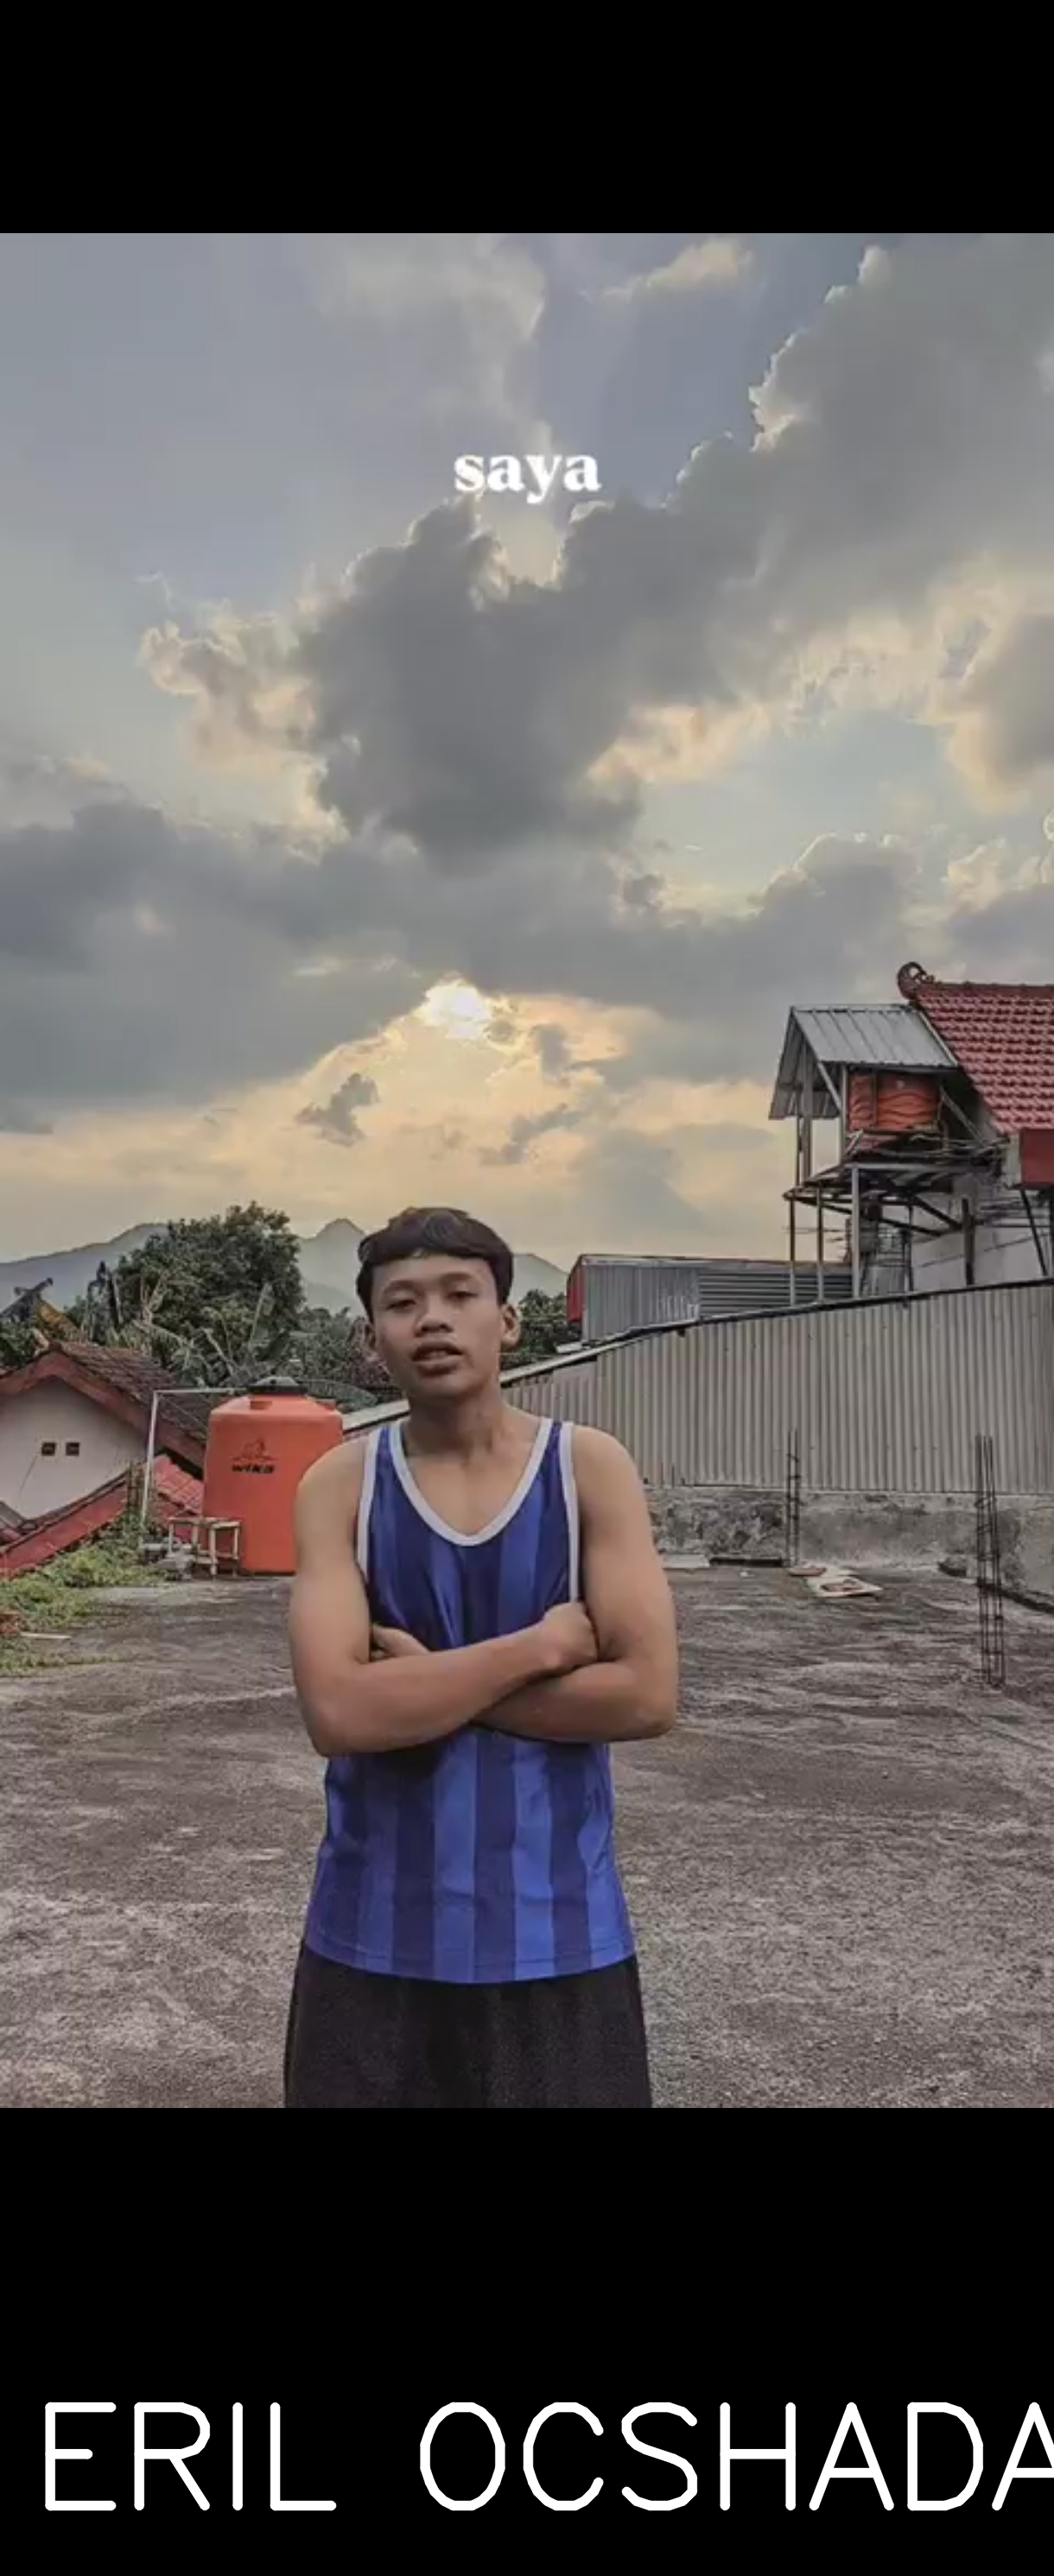

HASIL FOTO 2


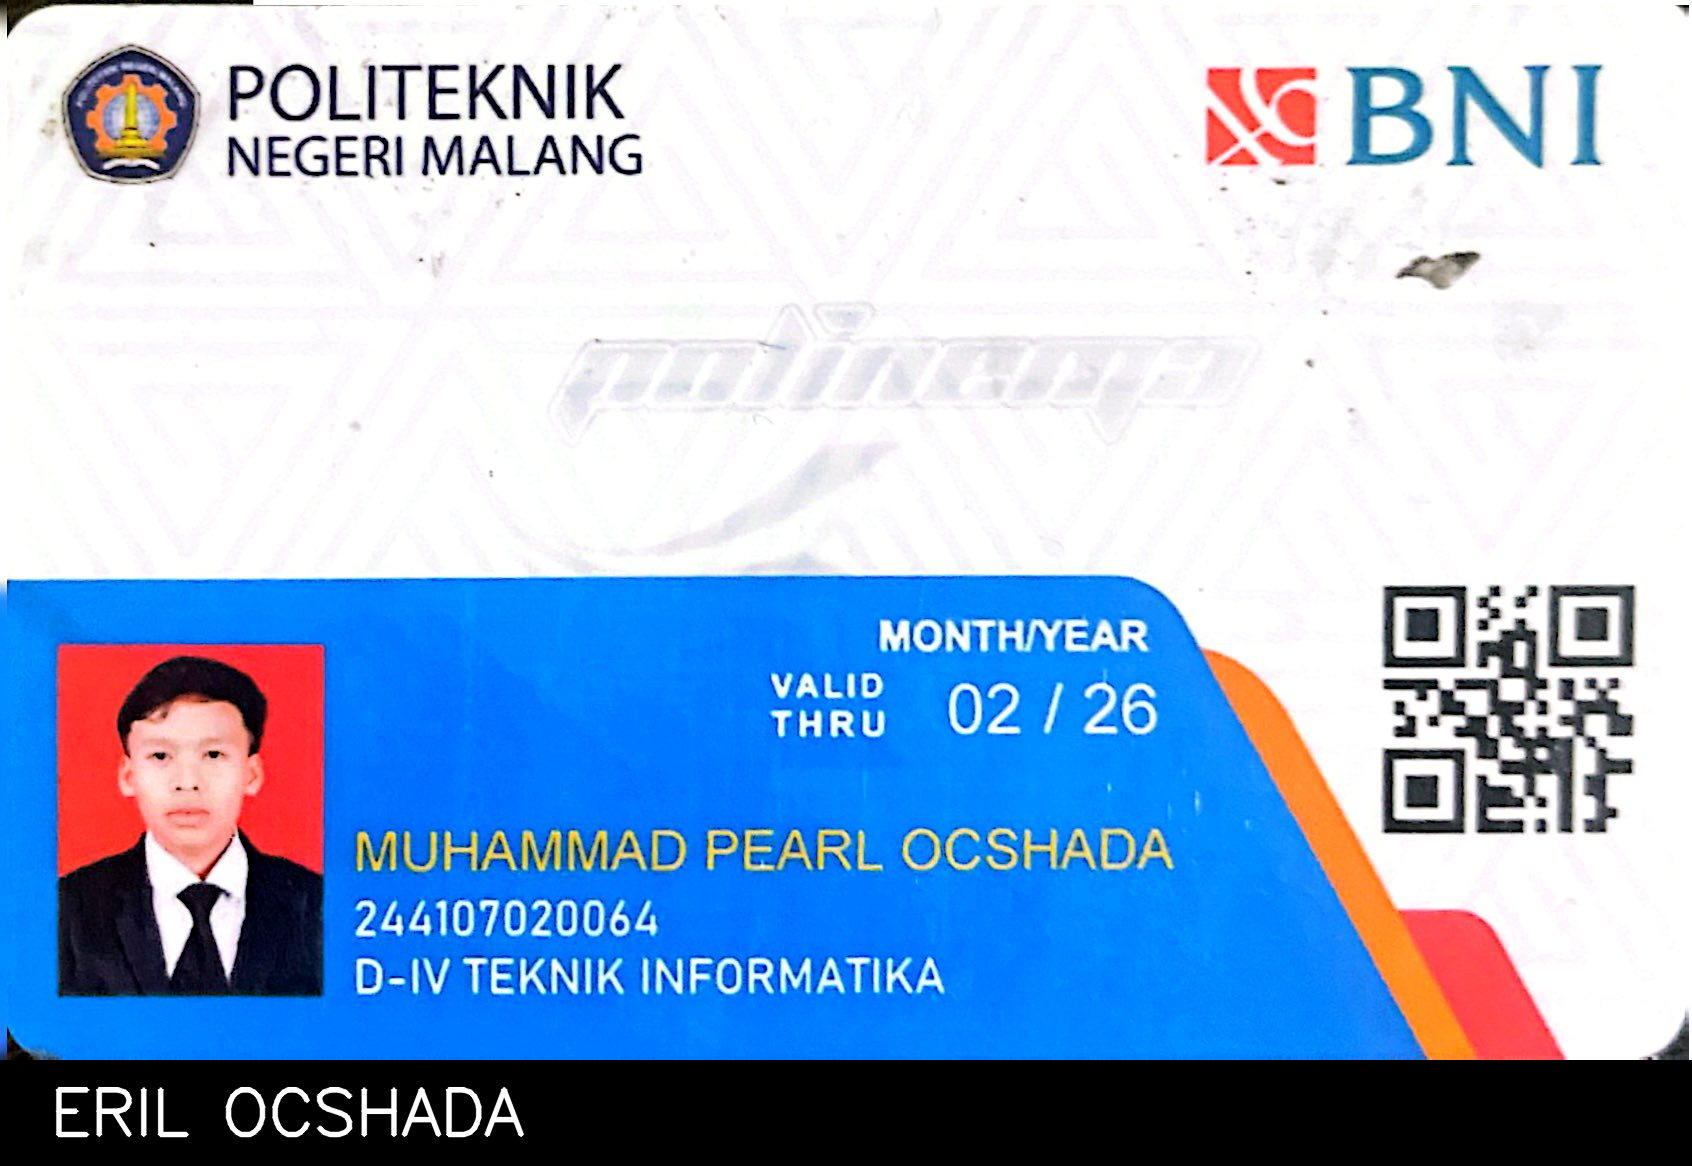

In [3]:
#Studi Kasus1
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow


def tambah_label(img, nama):

    # Mendapatkan ukuran gambar
    h, w = img.shape[:2]

    # Tinggi bar = 10% dari tinggi gambar
    tinggi_bar = int(h * 0.10)

    # Membuat canvas bar hitam
    bar = np.zeros(
        (tinggi_bar, w, 3),
        dtype=np.uint8
    )

    # Ukuran font menyesuaikan tinggi gambar
    ukuran_font = h / 500

    # Ketebalan teks menyesuaikan ukuran gambar
    ketebalan = max(1, int(h / 250))

    # Posisi teks
    posisi_x = int(w * 0.03)
    posisi_y = int(tinggi_bar * 0.70)

    # Menambahkan nama
    cv.putText(
        bar,
        nama,
        (posisi_x, posisi_y),
        cv.FONT_HERSHEY_SIMPLEX,
        ukuran_font,
        (255, 255, 255),
        ketebalan,
        cv.LINE_AA
    )

    # Menggabungkan gambar dengan bar
    hasil = np.vstack((img, bar))

    return hasil


# Membaca dua gambar
img1 = cv.imread('/content/drive/MyDrive/Foto/Screenshot_2025-03-07-12-08-48-573_com.miui.mediaviewer.jpg')
img2 = cv.imread('/content/drive/MyDrive/Data/Foto-KTM.jpg')

# Membuat label
hasil1 = tambah_label(img1, 'ERIL OCSHADA')
hasil2 = tambah_label(img2, 'ERIL OCSHADA')

# Menampilkan hasil
print("HASIL FOTO 1")
cv2_imshow(hasil1)

print("HASIL FOTO 2")
cv2_imshow(hasil2)

Ukuran gambar asli:
(1060, 1692, 3)

Ukuran thumbnail:
(1692, 1692, 3)

Hasil Thumbnail Marketplace:


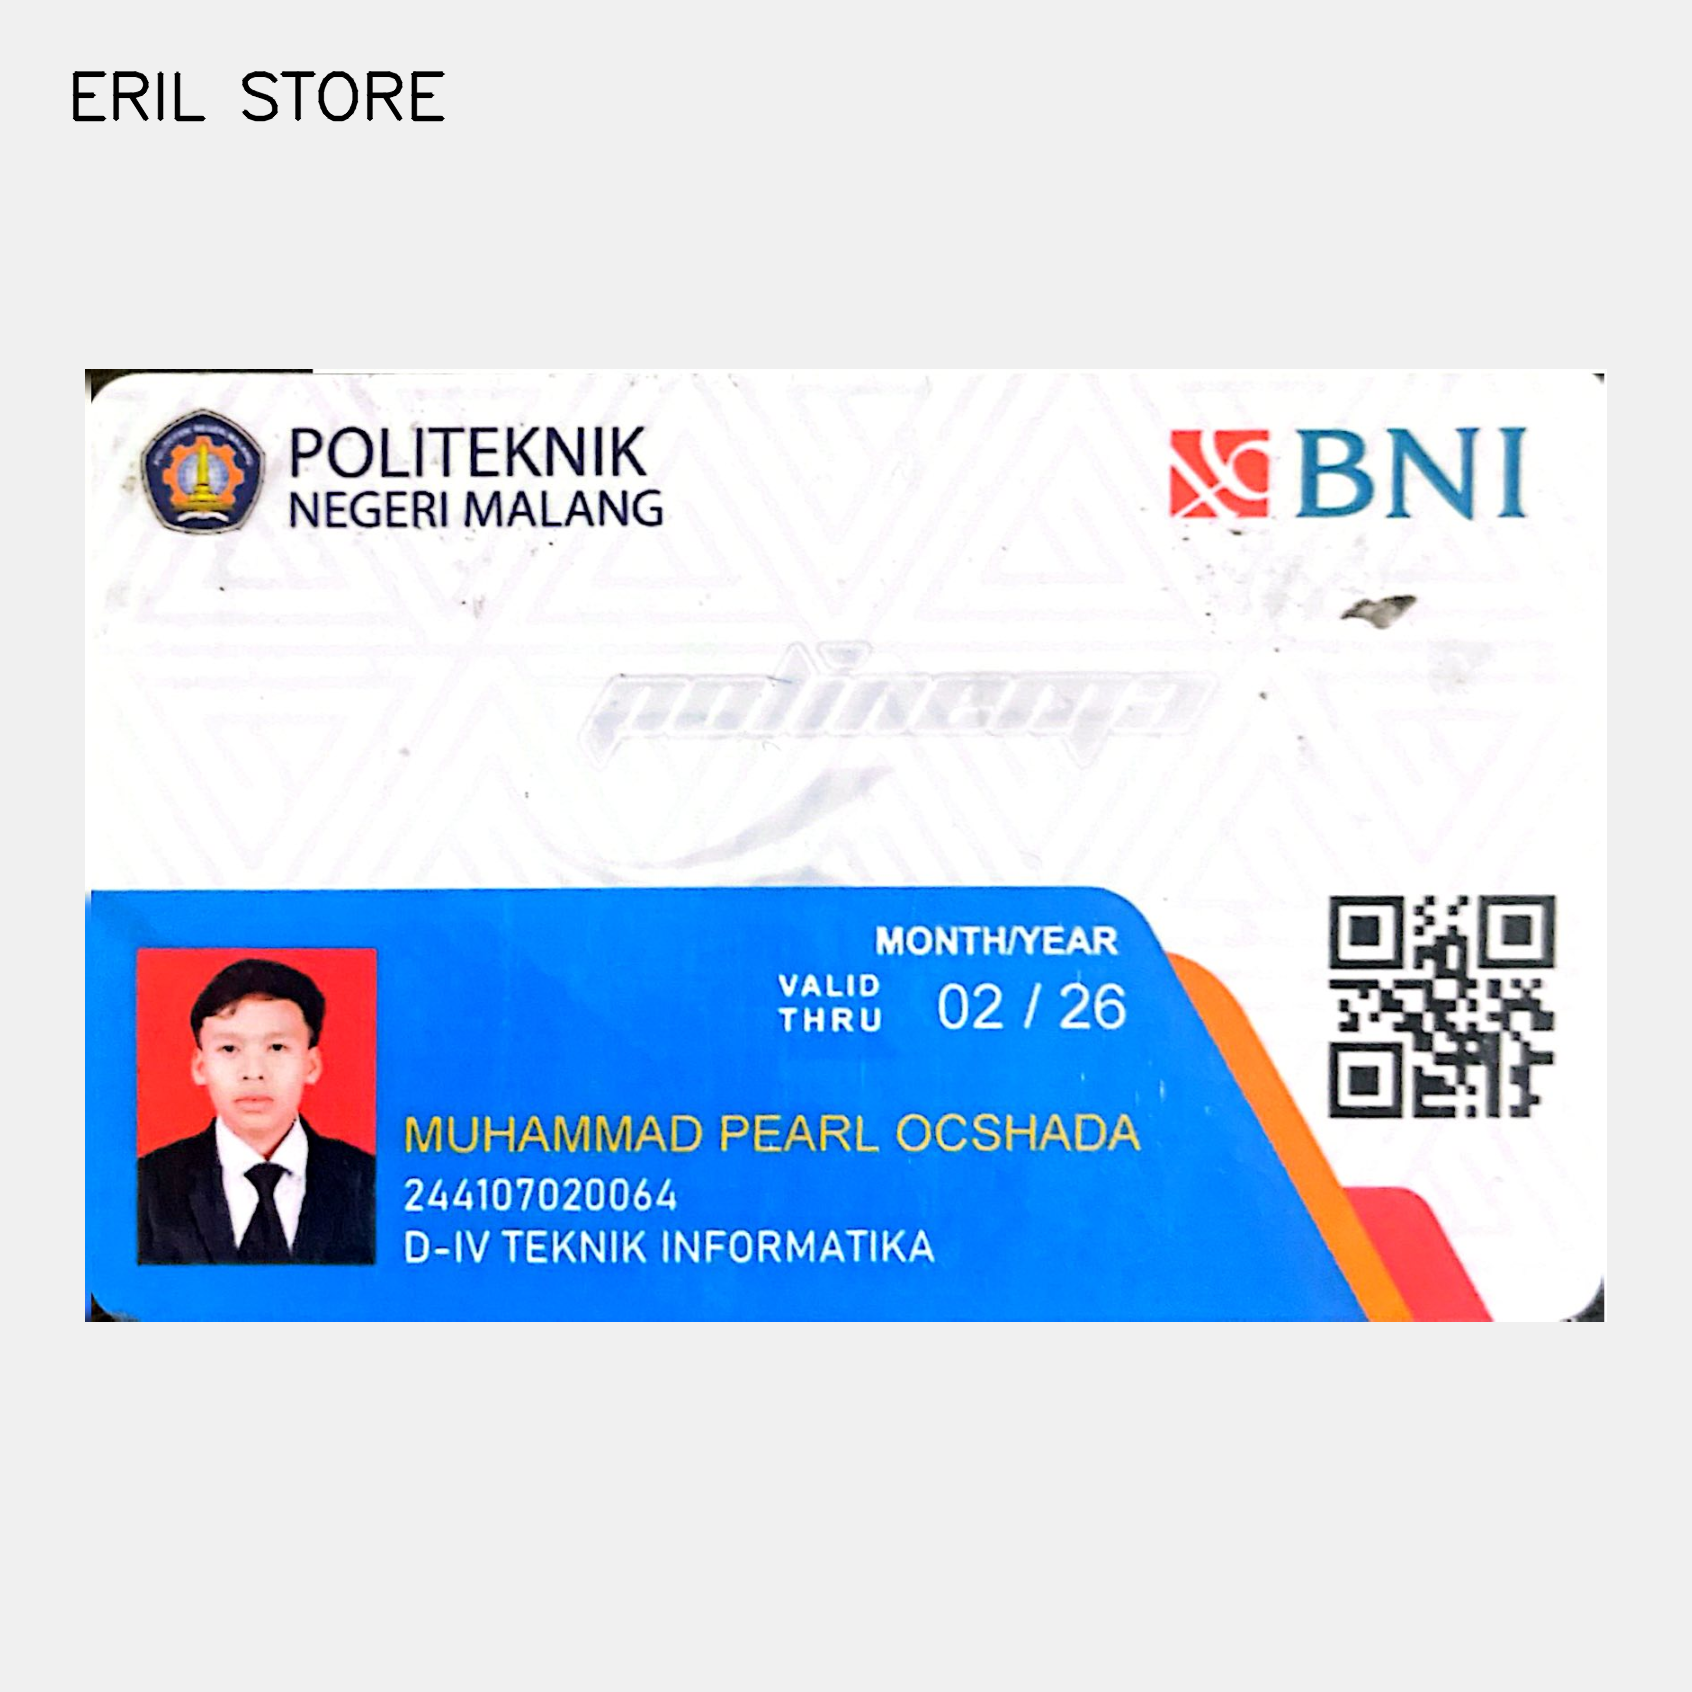

In [5]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow


def thumbnail_marketplace(img, nama_toko):

    # ==========================
    # 1. Mendapatkan ukuran asli
    # ==========================

    h, w = img.shape[:2]

    # Ukuran sisi thumbnail
    sisi = max(h, w)

    # ==========================
    # 2. Membuat canvas persegi
    # ==========================

    canvas = np.full(
        (sisi, sisi, 3),
        240,
        dtype=np.uint8
    )

    # ==========================
    # 3. Menentukan ukuran gambar
    # ==========================

    if w > h:

        # Landscape
        lebar_baru = int(sisi * 0.90)
        tinggi_baru = int(h * lebar_baru / w)

    else:

        # Portrait
        tinggi_baru = int(sisi * 0.90)
        lebar_baru = int(w * tinggi_baru / h)

    # Resize gambar
    gambar_resize = cv.resize(
        img,
        (lebar_baru, tinggi_baru)
    )

    # ==========================
    # 4. Menentukan posisi tengah
    # ==========================

    x = int((sisi - lebar_baru) / 2)
    y = int((sisi - tinggi_baru) / 2)

    # Menempelkan gambar ke canvas
    canvas[
        y:y + tinggi_baru,
        x:x + lebar_baru
    ] = gambar_resize

    # ==========================
    # 5. Menambahkan nama toko
    # ==========================

    ukuran_font = sisi / 800

    ketebalan = max(
        1,
        int(sisi / 400)
    )

    posisi_x = int(sisi * 0.04)
    posisi_y = int(sisi * 0.07)

    cv.putText(
        canvas,
        nama_toko,
        (posisi_x, posisi_y),
        cv.FONT_HERSHEY_SIMPLEX,
        ukuran_font,
        (0, 0, 0),
        ketebalan,
        cv.LINE_AA
    )

    return canvas


# ==========================
# Membaca gambar
# ==========================

img = cv.imread('/content/drive/MyDrive/Data/Foto-KTM.jpg')

if img is None:

    print("Gambar tidak ditemukan!")

else:

    hasil = thumbnail_marketplace(
        img,
        'ERIL STORE'
    )

    print("Ukuran gambar asli:")
    print(img.shape)

    print("\nUkuran thumbnail:")
    print(hasil.shape)

    print("\nHasil Thumbnail Marketplace:")
    cv2_imshow(hasil)